In [388]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
import xgboost as xg

In [389]:
df = pd.read_csv('credit_card_fraud_raw_dataset.csv')
df.head()

,transaction_id,amount,time_in_seconds,customer_age,customer_tenure_months,transaction_location,merchant_category,is_international,card_type,fraud
0,1,1873.33,74971,61,30,Bangalore,Electronics,0,Credit,0
1,2,4753.62,162,57,83,Bangalore,Clothing,1,Debit,1
2,3,3660.24,34742,60,49,Pune,Travel,0,Debit,1
3,4,2993.69,19675,39,89,Mumbai,Clothing,0,Debit,0
4,5,780.94,73997,37,16,Pune,Electronics,1,Credit,1


In [390]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          2000 non-null   int64  
 1   amount                  2000 non-null   float64
 2   time_in_seconds         2000 non-null   int64  
 3   customer_age            2000 non-null   int64  
 4   customer_tenure_months  2000 non-null   int64  
 5   transaction_location    2000 non-null   object 
 6   merchant_category       2000 non-null   object 
 7   is_international        2000 non-null   int64  
 8   card_type               2000 non-null   object 
 9   fraud                   2000 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 156.4+ KB


In [391]:
df.describe()

,transaction_id,amount,time_in_seconds,customer_age,customer_tenure_months,is_international,fraud
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2493.686000,42562.394500,46.598000,59.869000,0.146500,0.167500
std,577.494589,1460.761743,25230.308196,16.371207,33.693879,0.353695,0.373515
min,1.000000,17.090000,112.000000,18.000000,1.000000,0.000000,0.000000
25%,500.750000,1190.997500,20346.500000,33.000000,31.000000,0.000000,0.000000
50%,1000.500000,2537.250000,42510.500000,46.000000,60.000000,0.000000,0.000000
75%,1500.250000,3753.640000,64642.250000,61.000000,88.000000,0.000000,0.000000
max,2000.000000,4998.590000,86346.000000,74.000000,119.000000,1.000000,1.000000


In [392]:
df.duplicated().sum()

np.int64(0)

In [393]:
df_corr = df.select_dtypes(include=['number']).corr()

<Axes: >

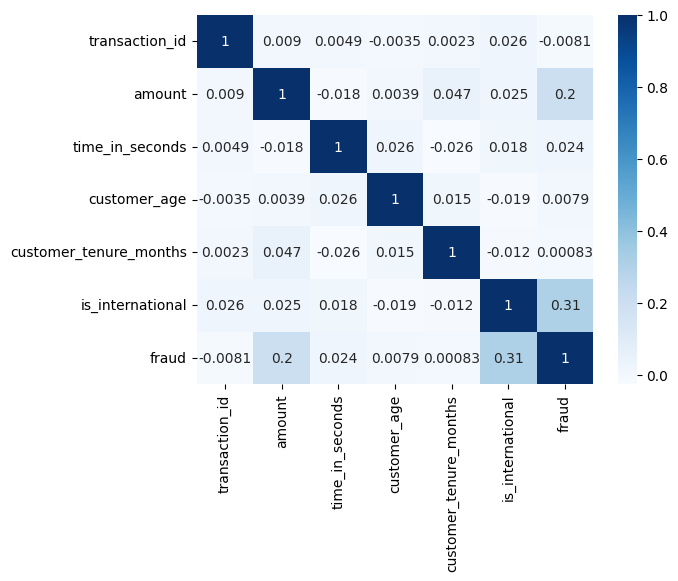

In [394]:
sns.heatmap(df_corr, annot=True, cmap='Blues')

In [395]:
X = df.drop(['transaction_id', 'fraud'], axis=1)
y = df['fraud']

In [396]:
categorical_cols = ['transaction_location', 'merchant_category', 'card_type']
numerical_cols = ['amount', 'time_in_seconds', 'customer_age', 'customer_tenure_months', 'is_international']

In [397]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

In [398]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [399]:
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(ratio)

4.970149253731344


In [400]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xg.XGBClassifier(objective='binary:logistic', eval_metric='aucpr', use_label_encoder=False))
])

In [401]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__scale_pos_weight': [1, ratio / 2, ratio] 
}

In [402]:
random_search = RandomizedSearchCV(
    xgb_pipeline, 
    param_distributions=param_grid, 
    n_iter=10, 
    scoring='f1', 
    cv=3, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)

In [403]:
print("Starting Hyperparameter Tuning... this may take a minute.")
random_search.fit(X_train, y_train)

Starting Hyperparameter Tuning... this may take a minute.
Fitting 3 folds for each of 10 candidates, totalling 30 fits


d:\internship pro\ml-project\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:10:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [404]:
print("Best F1 Score:", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

Best F1 Score: 0.40658655086256346
Best Parameters: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': np.float64(4.970149253731344), 'classifier__n_estimators': 100, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}


In [405]:
best_model = random_search.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

In [406]:
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = []

In [407]:
for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

In [408]:
best_thresh_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_thresh_idx]
max_f1 = f1_scores[best_thresh_idx]

In [409]:
print(f"Best Threshold: {best_thresh:.2f}")
print(f"Maximized F1-Score: {max_f1:.4f}")

Best Threshold: 0.29
Maximized F1-Score: 0.4379


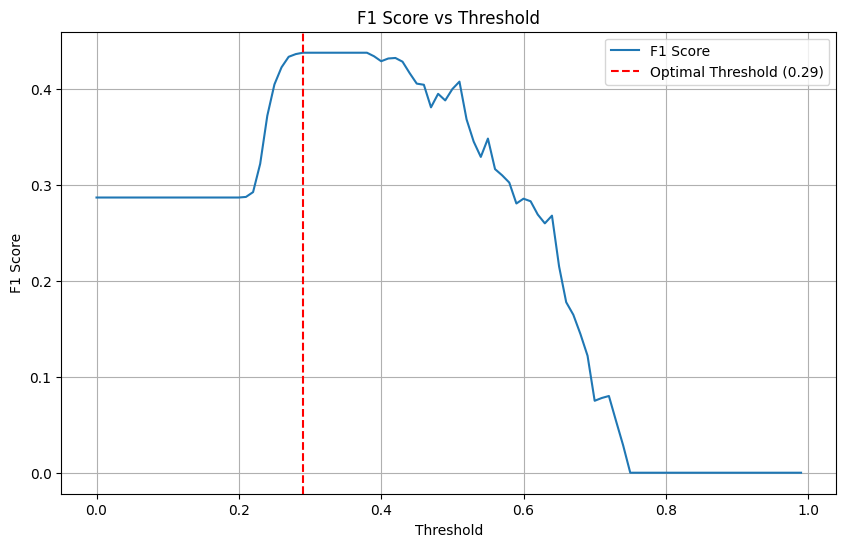

In [410]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Optimal Threshold ({best_thresh:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [411]:
y_final_pred = (y_proba >= best_thresh).astype(int)

In [412]:
print("\nFinal Classification Report (Optimized):")
print(classification_report(y_test, y_final_pred))


Final Classification Report (Optimized):
              precision    recall  f1-score   support

           0       1.00      0.48      0.65       333
           1       0.28      1.00      0.44        67

    accuracy                           0.57       400
   macro avg       0.64      0.74      0.54       400
weighted avg       0.88      0.57      0.62       400



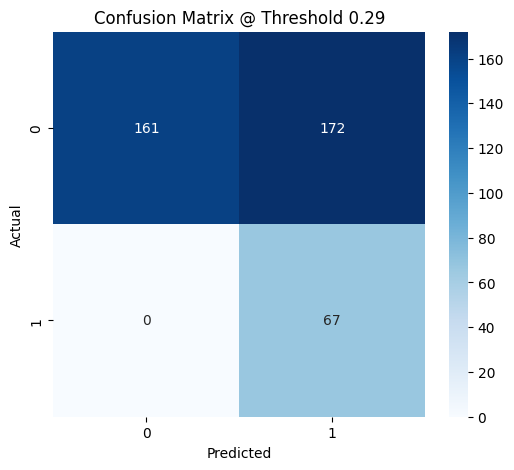

In [413]:
cm = confusion_matrix(y_test, y_final_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix @ Threshold {best_thresh:.2f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()